- aCM_SEMA3A positive likely to be VCS_distal

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

import scanpy.external as sce

In [2]:
# import session_info
# session_info.show()

In [3]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/home/kk837/rfs/rfs-teichlab-nfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

/home/kk837/rfs/rfs-teichlab-nfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [4]:
sc.settings.set_figure_params(dpi=80)

# Variables

In [5]:
adata_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/subsets'
celltype_a = 'VentricularCardiomyocytes'
celltype_b = 'AtrialCardiomyocytes'

In [6]:
latent_space = 'pca_harmony'

# Read in data

In [7]:
# read in
adata_a = sc.read_h5ad(f'{adata_dir}/{celltype_a}_lognorm.h5ad')
adata_b = sc.read_h5ad(f'{adata_dir}/{celltype_b}_lognorm.h5ad')
adata = adata_a.concatenate(adata_b,
                            batch_key=None, 
                            index_unique=None
                           )
pd.crosstab(adata.obs['fine_grain_manual'],adata.obs['coarse_grain_tacco'])

/tmp/ipykernel_702513/1331413740.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_a.concatenate(adata_b,
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['C194-HEA-0-FFPE-1_aabnojal-1', 'C194-HEA-0-FFPE-1_aabodime-1', 'C194-HEA-0-FFPE-1_aaboibjl-1', 'C194-HEA-0-FFPE-1_aaboiipk-1', 'C194-HEA-0-FFPE-1_aabojcog-1']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


coarse_grain_tacco,AtrialCardiomyocytes,VentricularCardiomyocytes
fine_grain_manual,,
AtrialCardiomyocytesCycling,7495,0
AtrialCardiomyocytesLeft,5830,0
AtrialCardiomyocytesRight,19866,0
AtrialCardiomyocytesRightSEMA3Apos,1029,0
AtrialCardiomyocytesTransitional,812,0
AtrialCardiomyocytes_DoubletWithFB,1841,0
AtrioventricularNodePacemakerCells,1155,0
LowCountsCells,11739,43893
PacemakerCellsCycling,235,0


In [8]:
adata.X.data[:5]

array([3.03882604, 3.03882604, 3.03882604, 3.03882604, 3.03882604])

# Re-integration

In [9]:
adata_lognorm = adata.copy()
# filter genes
sc.pp.filter_genes(adata_lognorm, min_cells=3)
# log-normalise the count
sc.pp.normalize_total(adata_lognorm,target_sum=1e4)
sc.pp.log1p(adata_lognorm)
adata_lognorm.X.data[:5]

array([3.3020589 , 3.3020589 , 3.3020589 , 3.59318525, 3.49434664])

In [10]:
# PCA
# Create simple reduced dimensional space using PCA
sc.tl.pca(adata_lognorm)

# Harmony
import scanpy.external as sce
sce.pp.harmony_integrate(adata_lognorm, 'tissue_block_id', basis='X_pca', adjusted_basis='X_pca_harmony')

2026-04-17 17:02:25,181 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-17 17:02:39,109 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-17 17:02:39,906 - harmonypy - INFO - Iteration 1 of 10
2026-04-17 17:03:32,909 - harmonypy - INFO - Iteration 2 of 10
2026-04-17 17:04:39,580 - harmonypy - INFO - Iteration 3 of 10
2026-04-17 17:05:49,023 - harmonypy - INFO - Iteration 4 of 10
2026-04-17 17:06:58,650 - harmonypy - INFO - Iteration 5 of 10
2026-04-17 17:07:53,853 - harmonypy - INFO - Iteration 6 of 10
2026-04-17 17:08:19,705 - harmonypy - INFO - Iteration 7 of 10
2026-04-17 17:08:45,516 - harmonypy - INFO - Converged after 7 iterations


In [11]:
# kNN graph and umap
# add to original adata
adata.uns['pca'] = adata_lognorm.uns['pca'].copy()
adata.obsm['X_pca'] = adata_lognorm.obsm['X_pca'].copy()
adata.obsm['X_pca_harmony'] = adata_lognorm.obsm['X_pca_harmony'].copy()
adata.varm['PCs'] = adata_lognorm.varm['PCs'].copy()
adata

AnnData object with n_obs × n_vars = 224889 × 4998
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

In [12]:
key_added = 'pca_harmony'
print("making kNN graph...")
sc.pp.neighbors(adata,use_rep=f"X_{key_added}",key_added=key_added)
print("computing UMAP coordinates...")
sc.tl.umap(adata, min_dist=0.2, neighbors_key=key_added)
adata.obsm[f"X_umap_{key_added}"]=adata.obsm["X_umap"] # rename the generic X_umap coordinates
del adata.obsm["X_umap"]

making kNN graph...


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


computing UMAP coordinates...


# Plotting

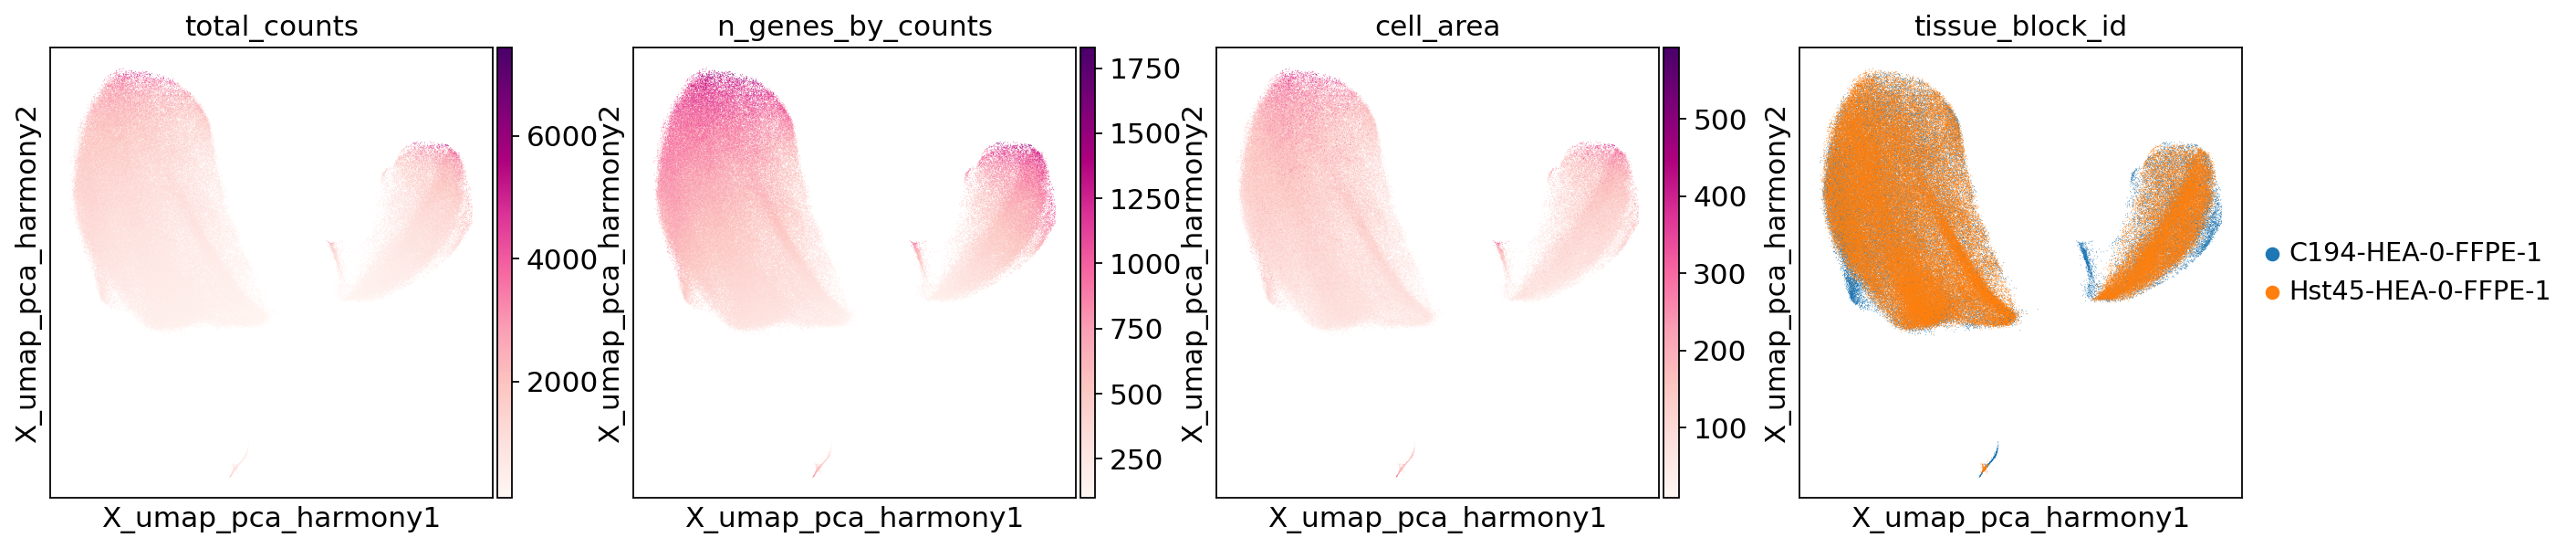

In [13]:
sc.pl.embedding(adata, basis=f"X_umap_{latent_space}",
                color=['total_counts','n_genes_by_counts','cell_area','tissue_block_id'],
                    wspace=0.2,cmap='RdPu',vmax='p100')

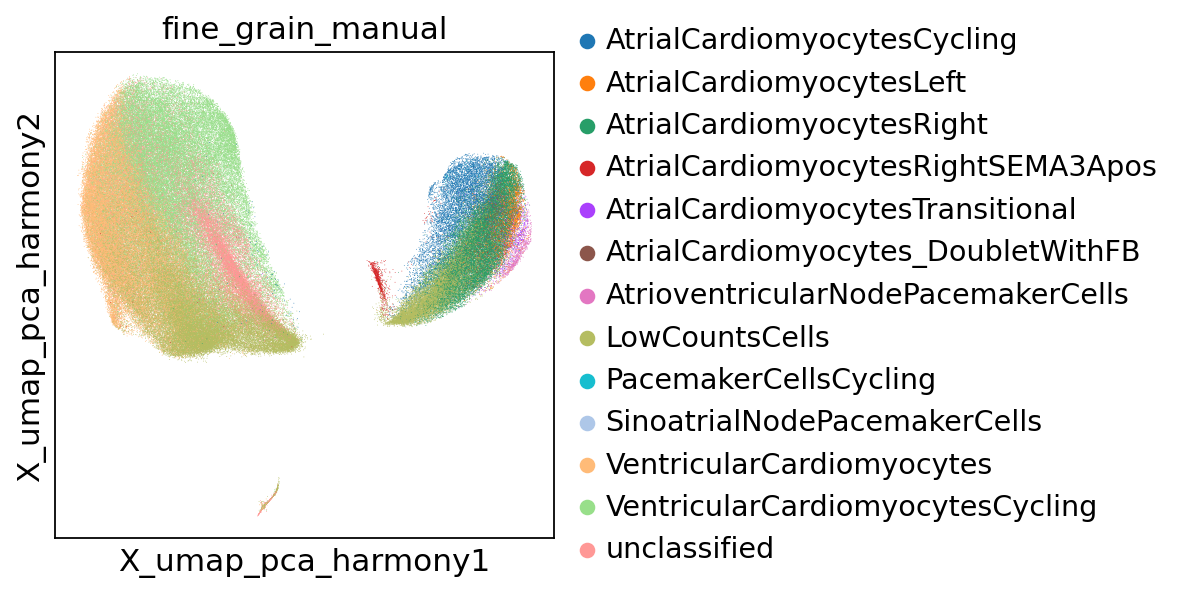

In [14]:
sc.pl.embedding(adata, basis=f"X_umap_{latent_space}",
                color=['fine_grain_manual'],
                    wspace=0.2,cmap='RdPu',vmax='p100')

In [10]:
markers = {
    'generic CM marker':['TTN', 'TNNT2','MYH6'], 
    'vCM':['MYH7', 'MYL2', 'FHL2'],
    'aCM':['NPPA', 'MYL7', 'MYL4'],
    'SANPC':['TBX3','TBX18','SHOX2','HCN1','HCN4','CACNA1D', 'GJA1','VSNL1'],
    'AVNPC':['GREB1L','GNG11','NRXN3','RSPO3'],
    'aCM_left':['PITX2','KCNMB2','PCDH7','RYR3','MBP'],
    'aCM_right':['NTM','ROR1','KIF26B','PLCL1','ANGPT1'],
    'VentricularConductionSystemDistal':['EPHA4',
  'CRNDE',
  'NPPA',
  'SEMA3A',
  'GABRB2',
  'SEMA3A',
  'NTN1',
  'EPHA4',
  'GABRB2'],
 'VentricularCardiomyocytesRightCompact': ['PRRX1', 'CYP2J2', 'ACTN2'],
 'VentricularCardiomyocytesLeftTrabeculated': ['CRNDE'],
 'VentricularCardiomyocytesLeftCompact': ['SLC1A3'],
 'VentricularConductionSystemProximal': ['TBX3',
  'COL18A1',
  'CXCL12',
  'TBX3',
  'NIBAN1'],
 'VentricularCardiomyocytesRightTrabeculated': ['FHL2',
  'SPOCK1',
  'CCDC141',
  'ENOX1'],
 'Cycling': ['MKI67']
}

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in list(adata.var_names)]

categories: AtrialCardiomyocytesCycling, AtrialCardiomyocytesLeft, AtrialCardiomyocytesRight, etc.
var_group_labels: generic CM marker, vCM, aCM, etc.


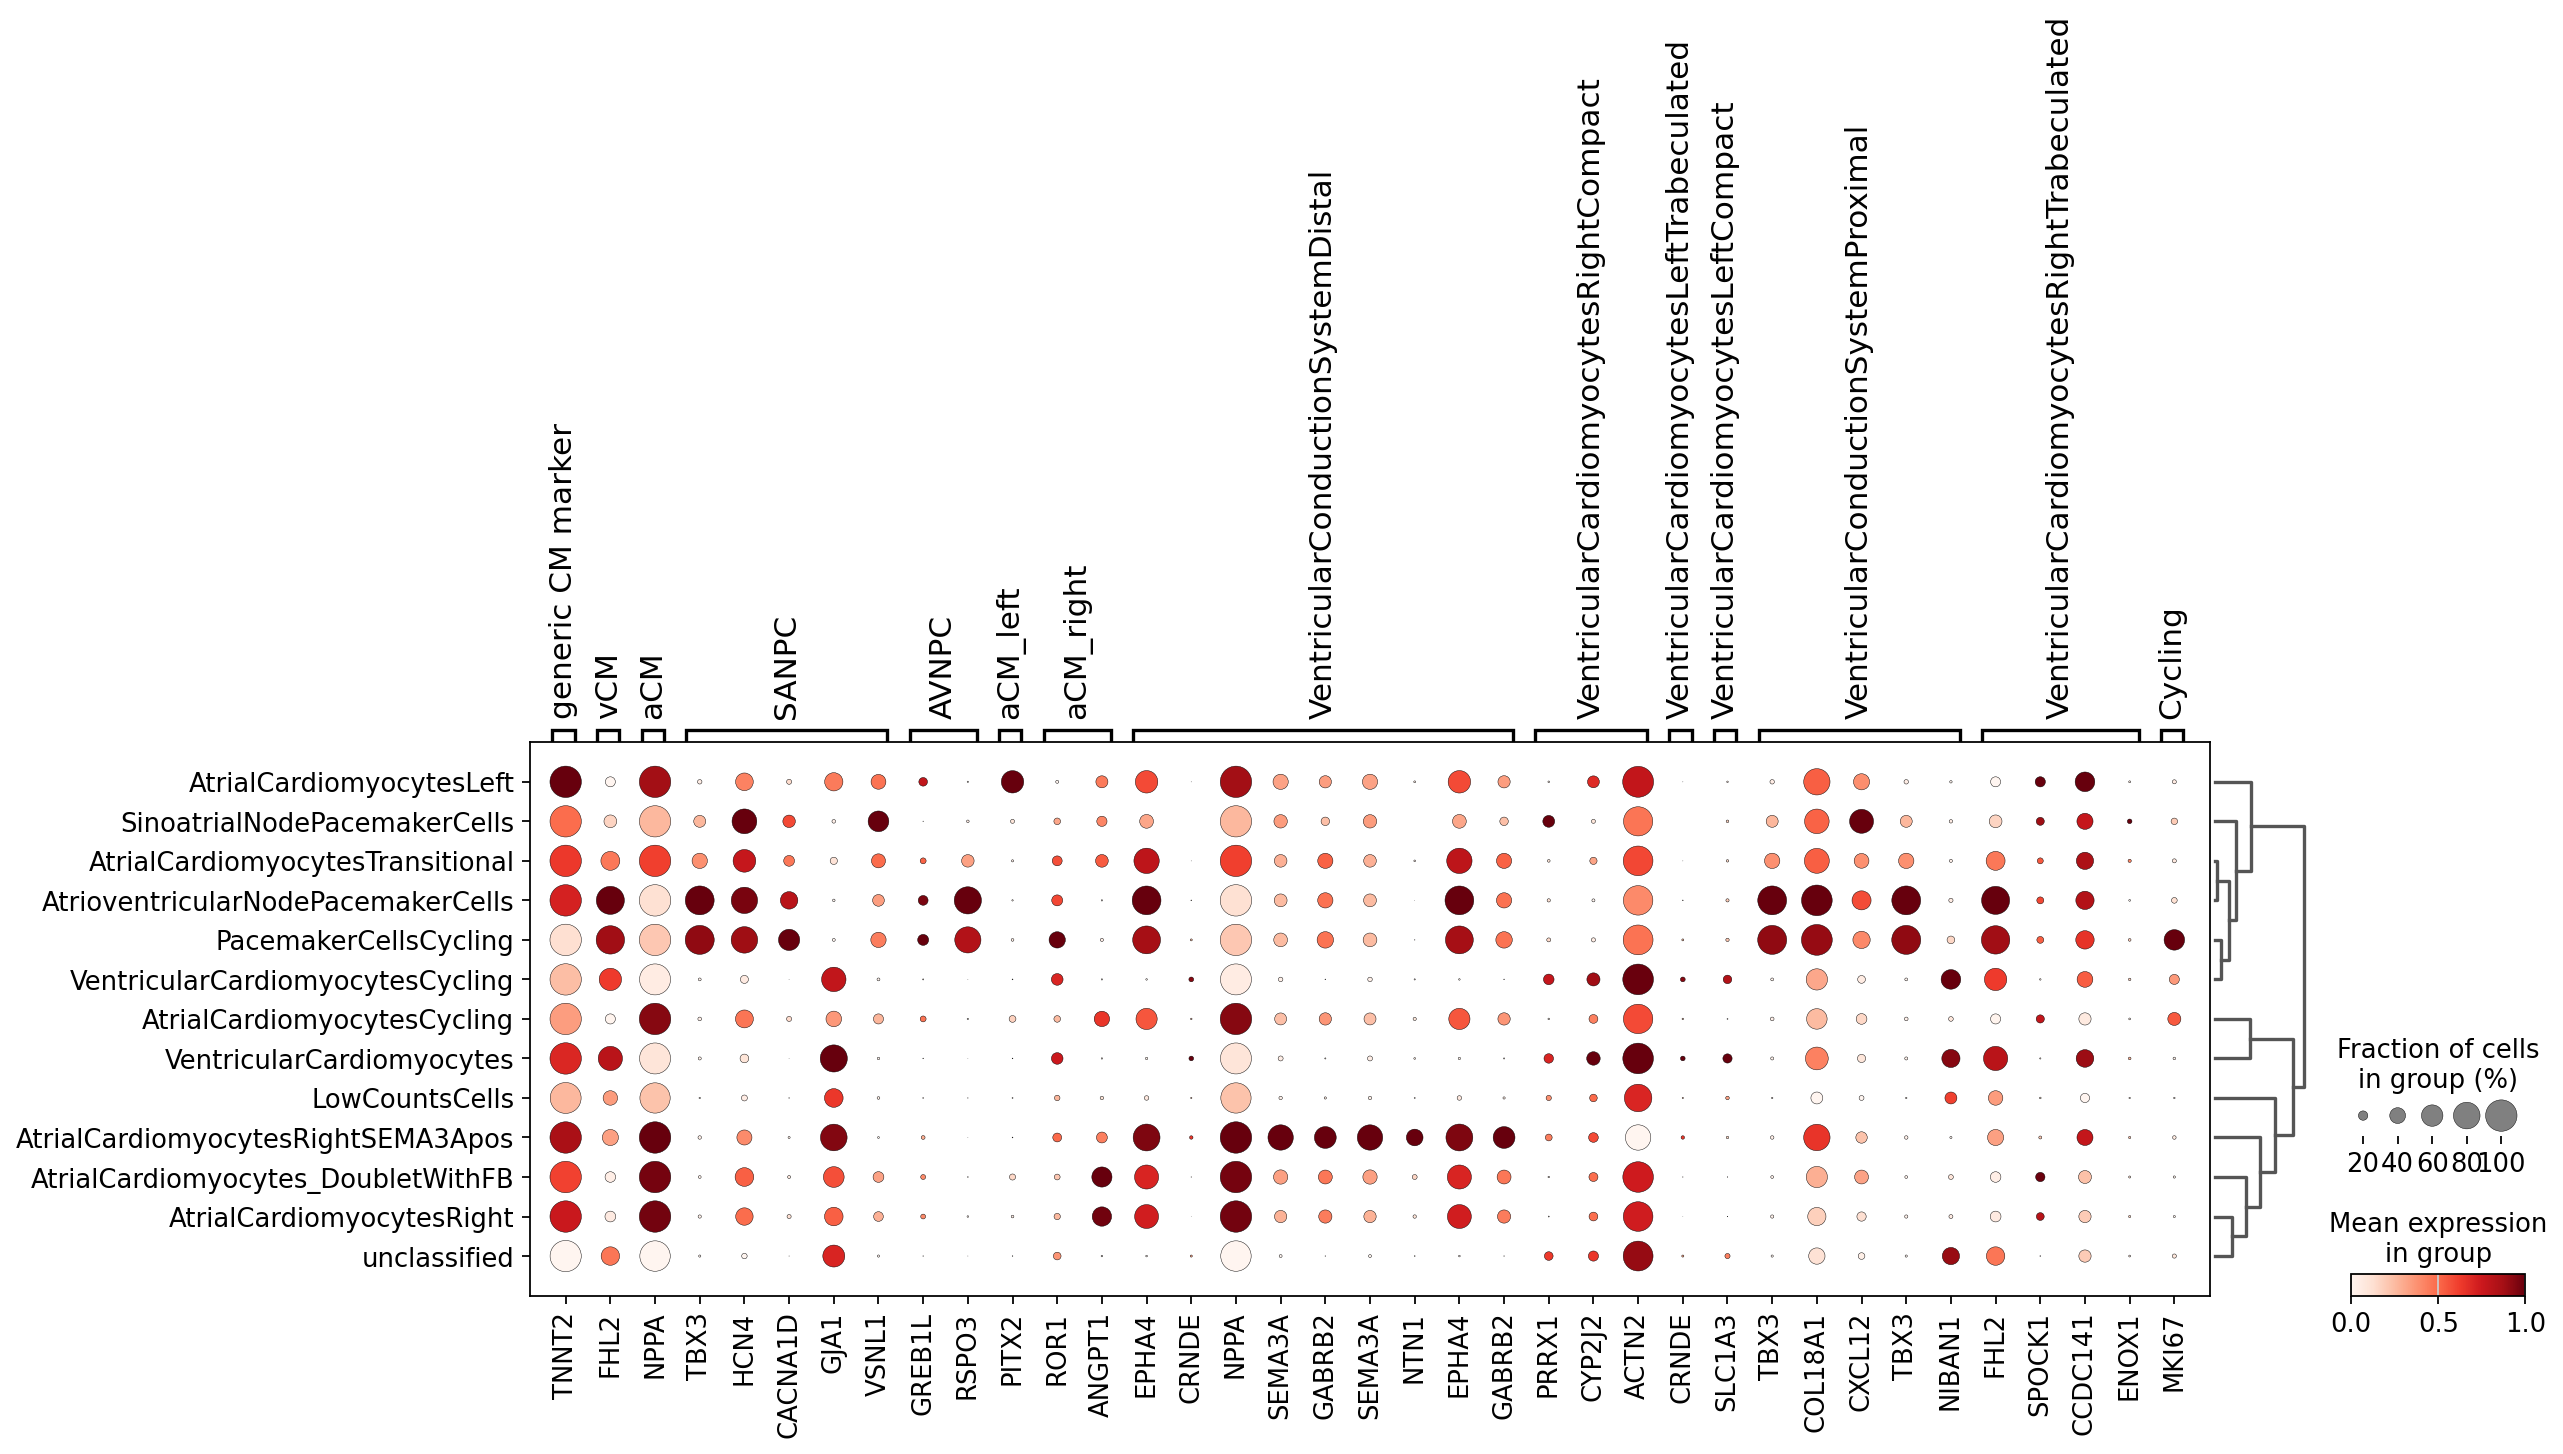

In [11]:
sc.tl.dendrogram(adata,groupby='fine_grain_manual')
sc.pl.dotplot(adata,
              var_names=markers,
              groupby='fine_grain_manual',
              standard_scale='var',
              dendrogram=True
             )

In [ ]:
-> "AtrialCardiomyocytesRightSEMA3Apos" looks like "vCM_distal"

# Rename & Save

In [12]:
adata_b.obs.replace({'fine_grain_manual':{
    "AtrialCardiomyocytesRightSEMA3Apos":'VentricularConductionSystemDistal'
}}, inplace=True)
adata_b.obs['fine_grain_manual'].value_counts()

/tmp/ipykernel_702513/927834601.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_b.obs.replace({'fine_grain_manual':{


fine_grain_manual
AtrialCardiomyocytesRight             19866
LowCountsCells                        11739
AtrialCardiomyocytesCycling            7495
AtrialCardiomyocytesLeft               5830
AtrialCardiomyocytes_DoubletWithFB     1841
AtrioventricularNodePacemakerCells     1155
VentricularConductionSystemDistal      1029
AtrialCardiomyocytesTransitional        812
SinoatrialNodePacemakerCells            246
PacemakerCellsCycling                   235
unclassified                             65
Name: count, dtype: int64

In [13]:
# save
adata_b.write(f'{adata_dir}/{celltype_b}_lognorm.h5ad')
print(f'{adata_dir}/{celltype_b}_lognorm.h5ad')

/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/subsets/AtrialCardiomyocytes_lognorm.h5ad


# Plot on sections

In [14]:
# load original adata with spatial coordinates
adata_ori = sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_celltype-sel_raw.h5ad',
                        backed='r')
adata.obsm['spatial'] = adata_ori[adata.obs_names].obsm['spatial'].copy()

In [15]:
adata.obs.replace({'fine_grain_manual':{
    "AtrialCardiomyocytesRightSEMA3Apos":'VentricularConductionSystemDistal'
}}, inplace=True)

/tmp/ipykernel_702513/204061074.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({'fine_grain_manual':{


/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


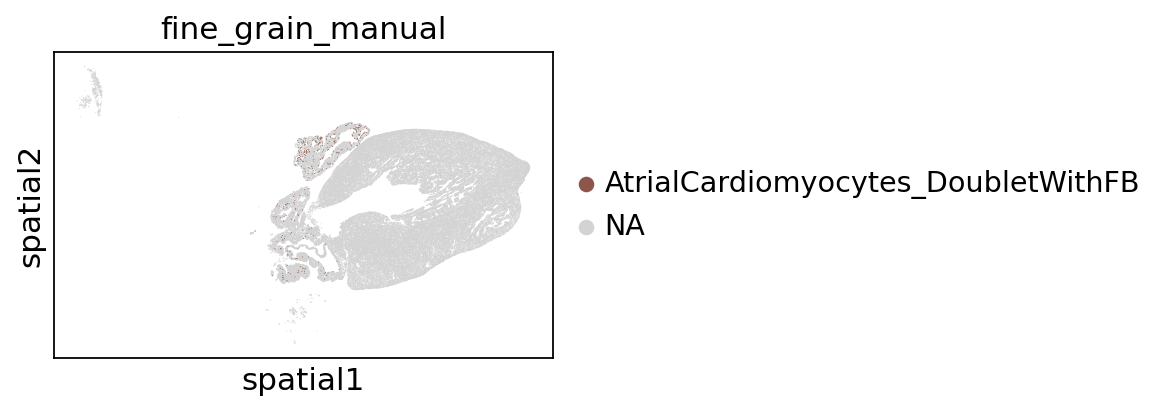

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


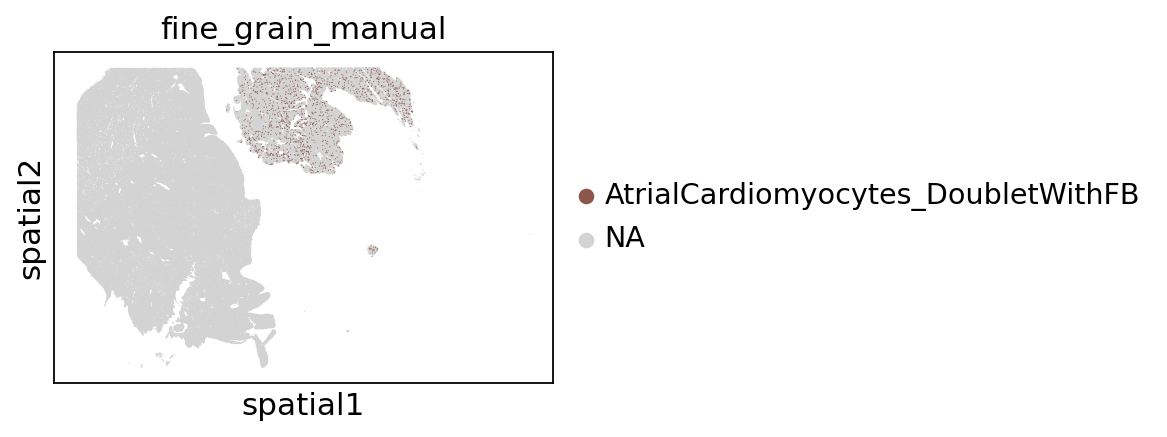

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


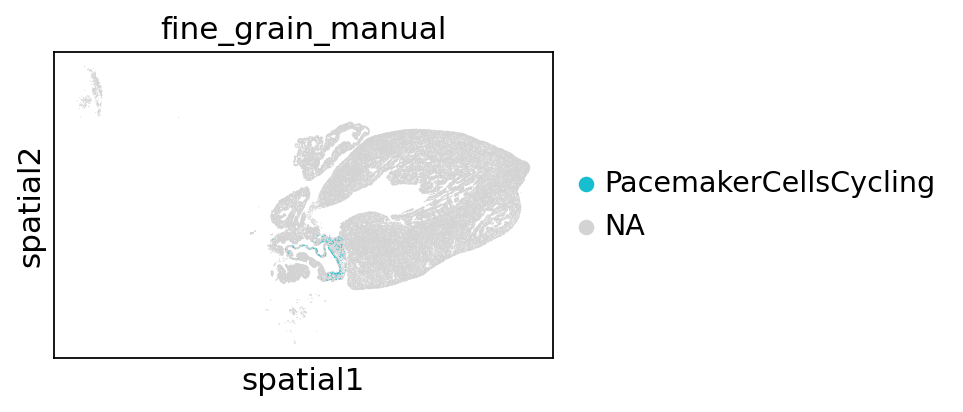

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


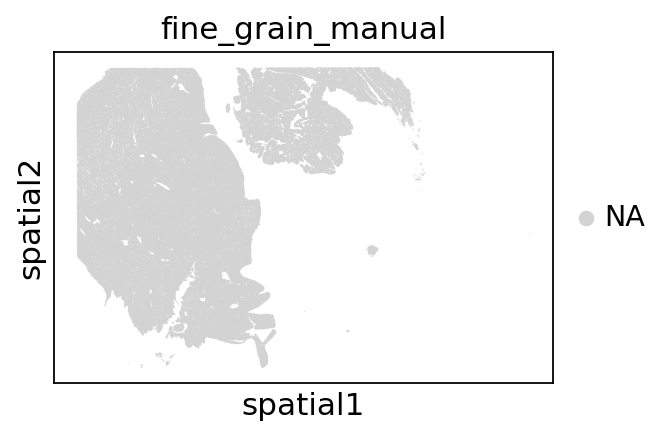

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


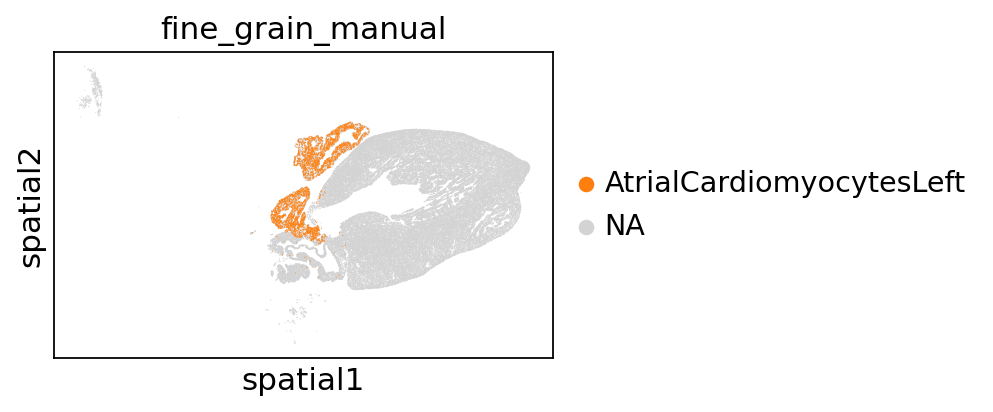

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


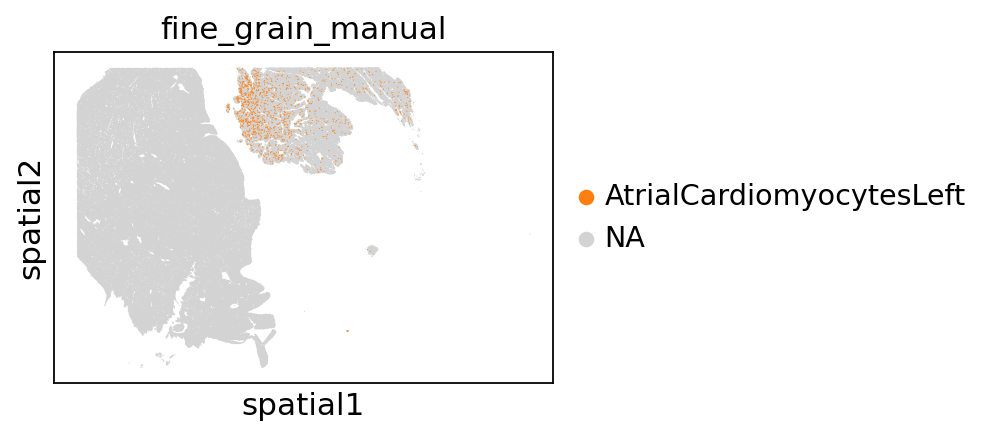

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


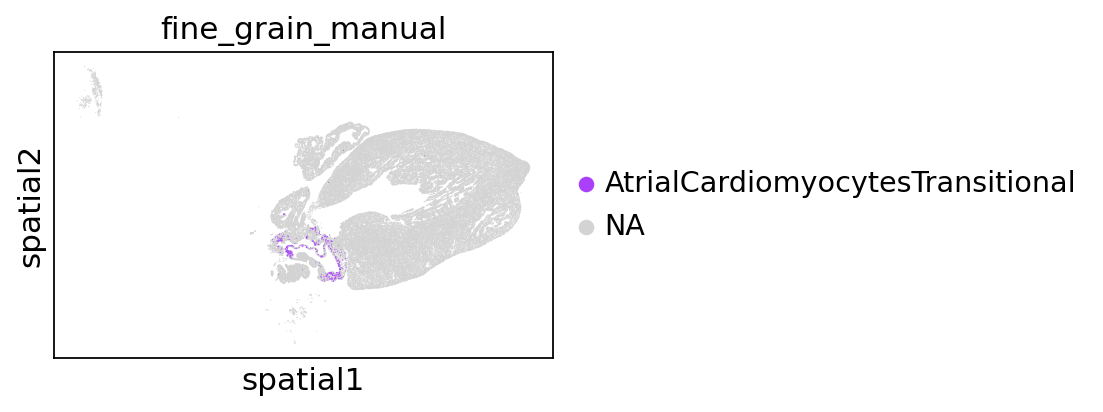

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


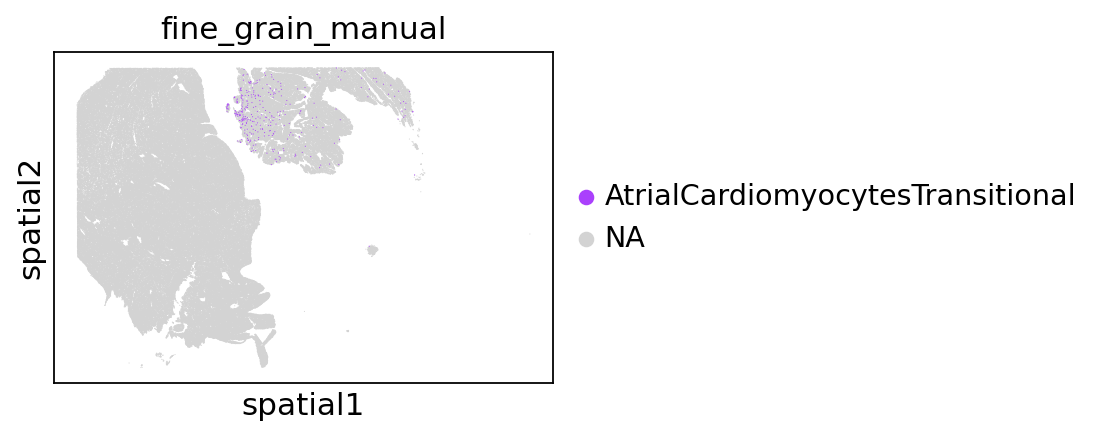

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


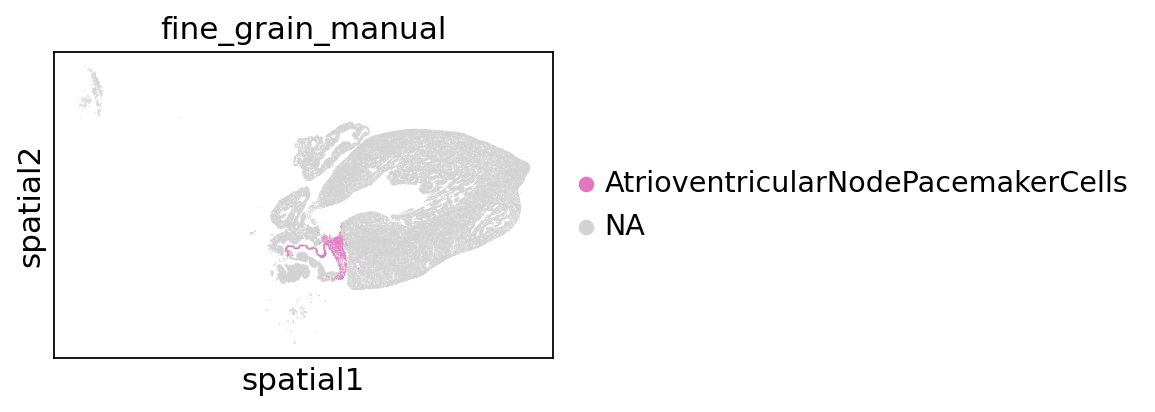

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


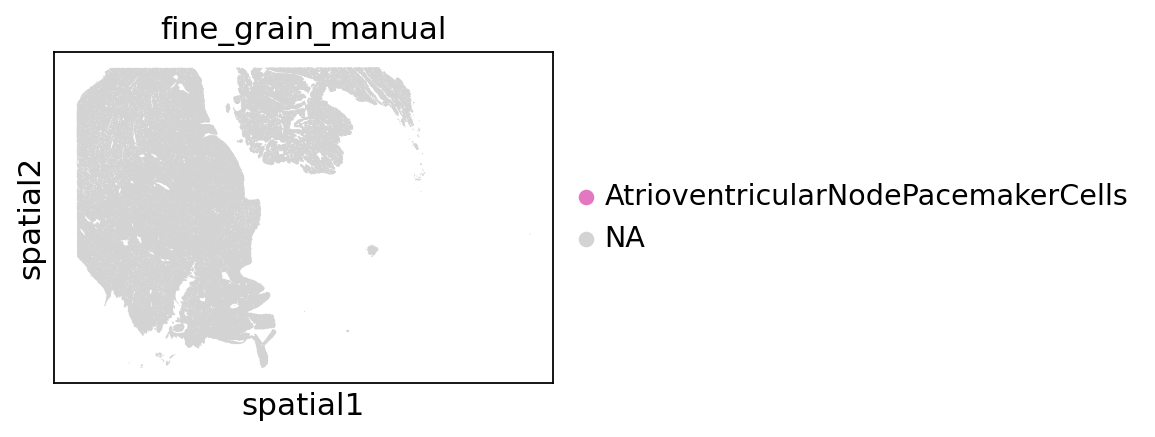

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


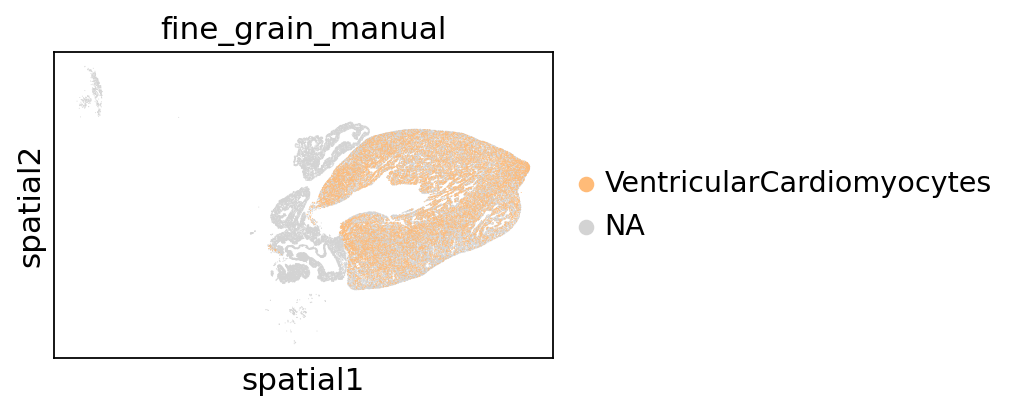

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


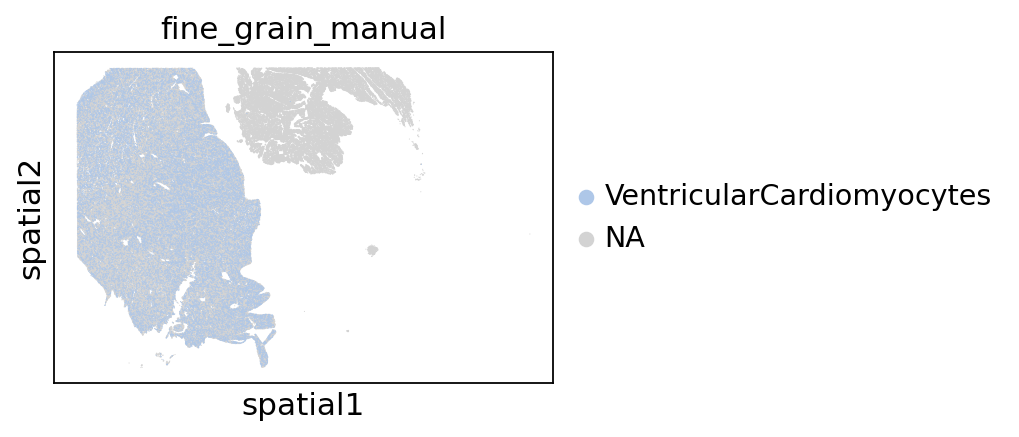

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


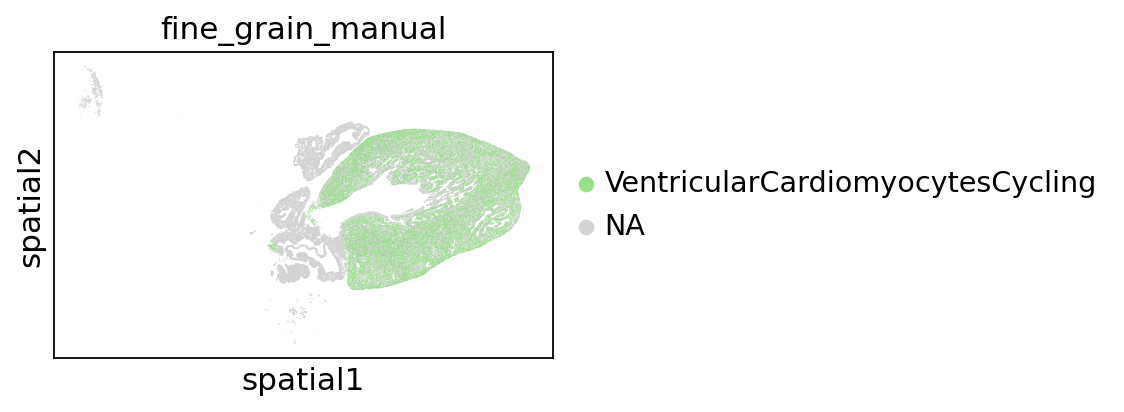

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


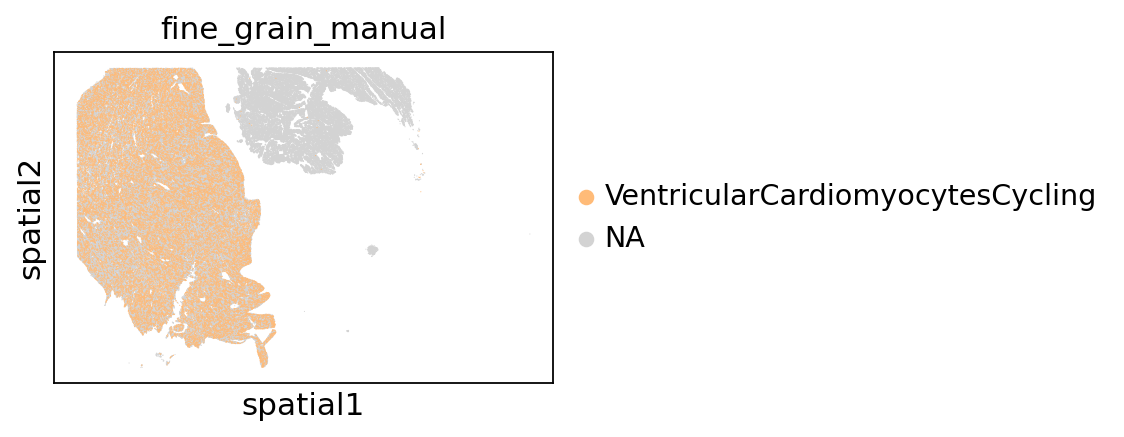

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


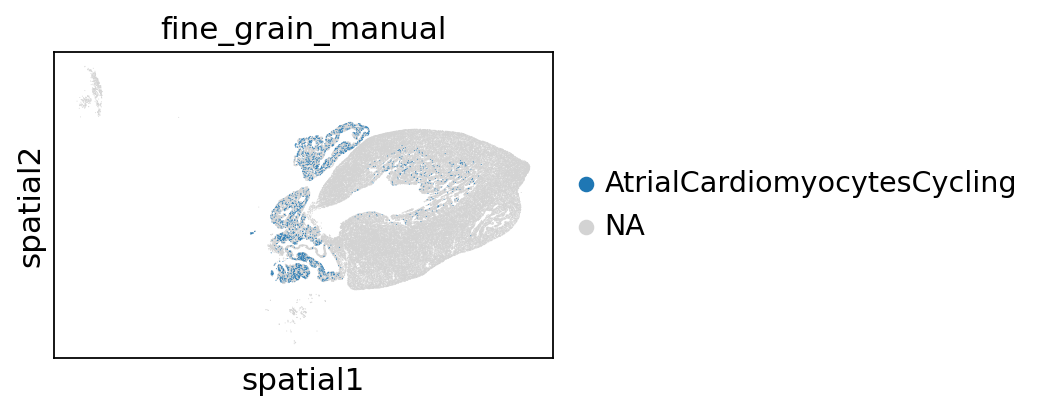

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


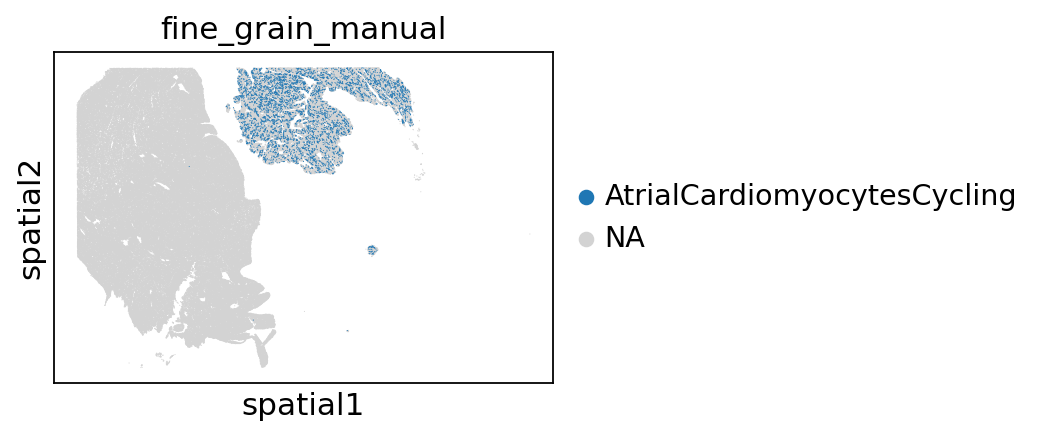

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


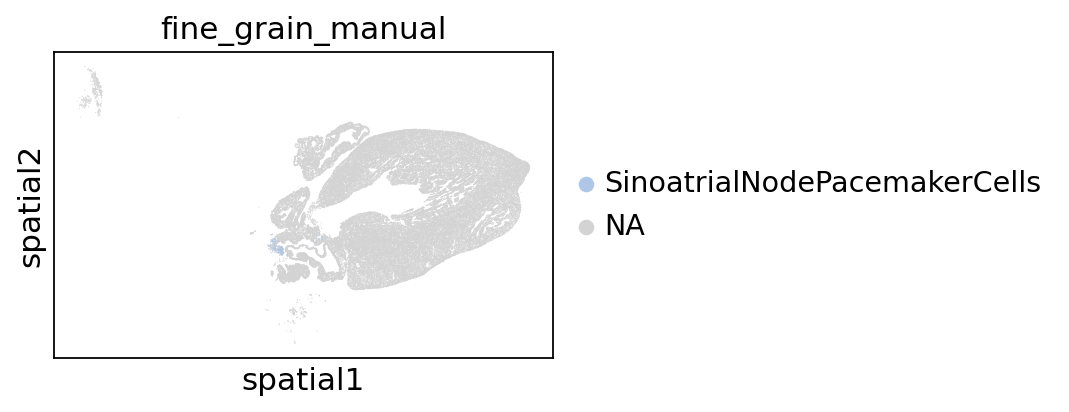

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


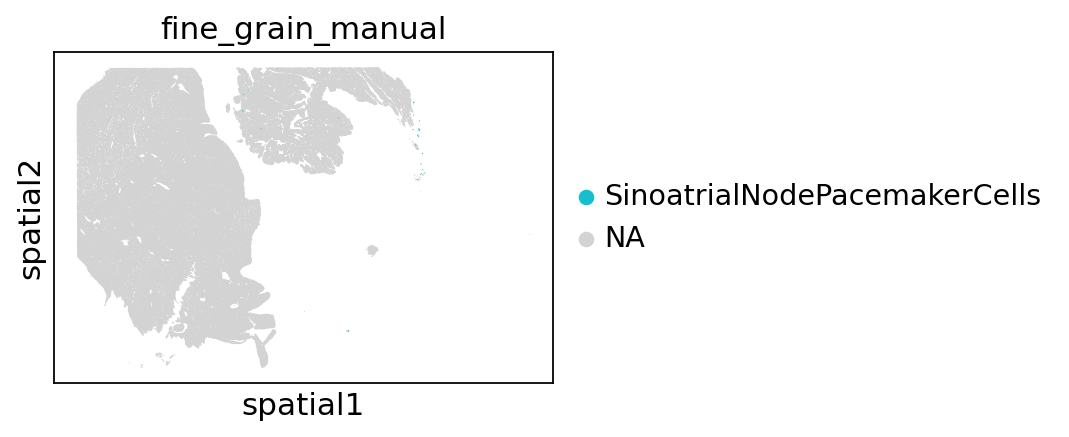

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


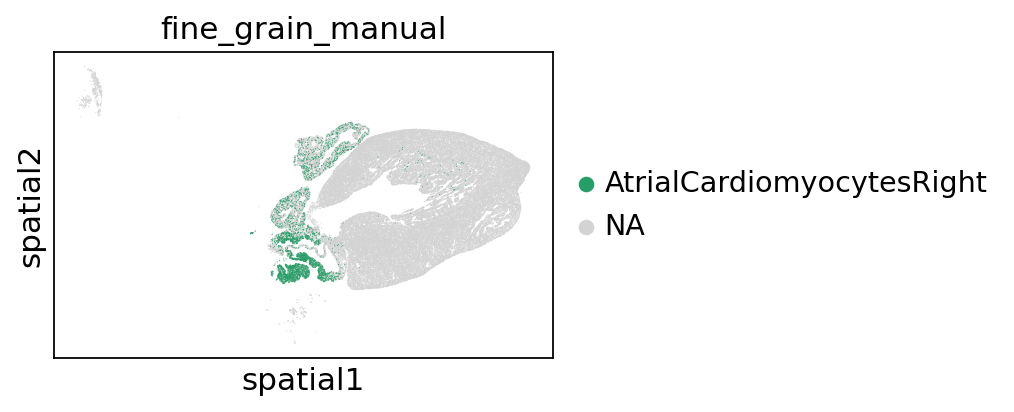

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


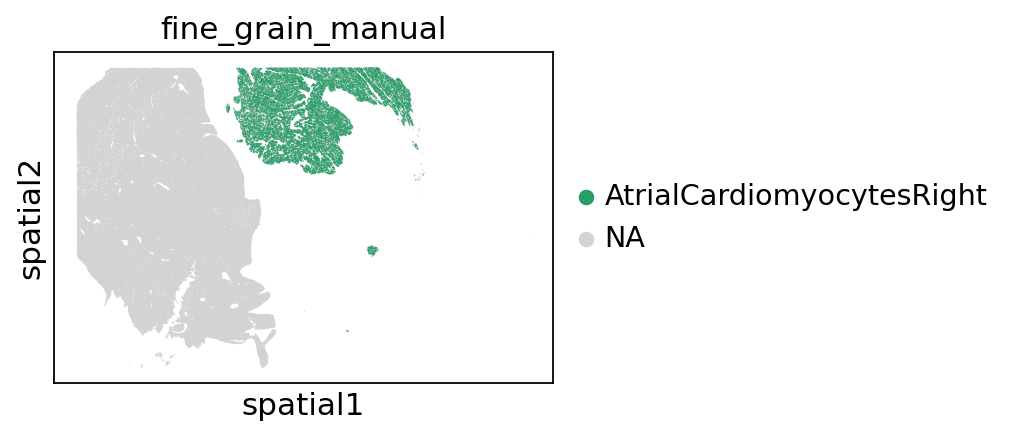

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


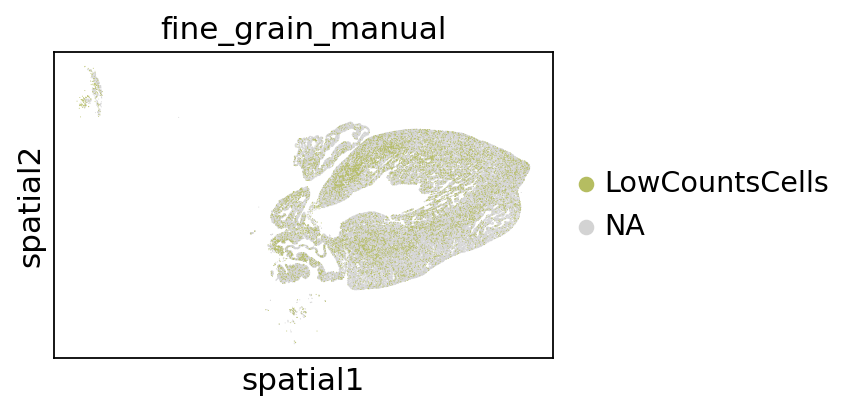

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


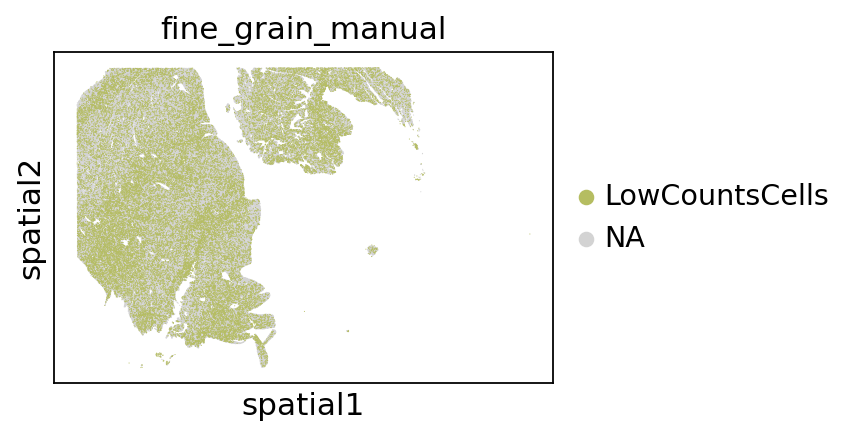

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


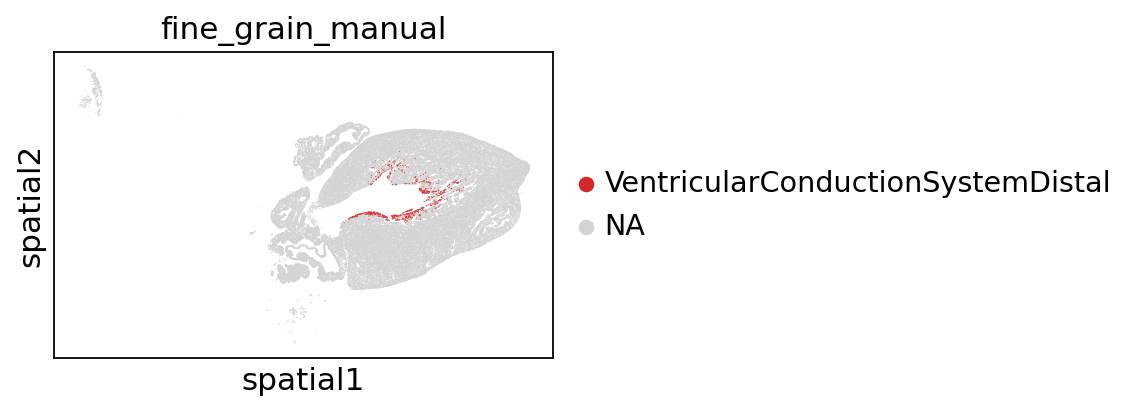

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


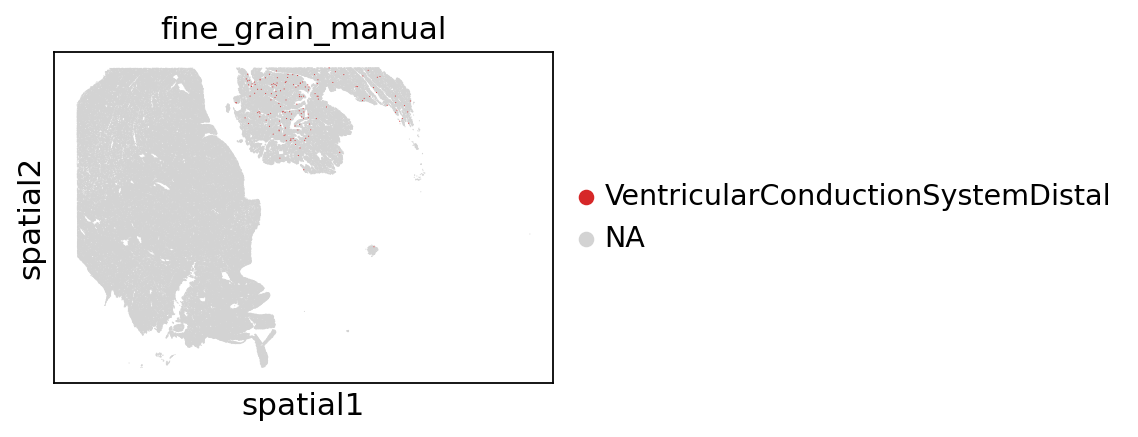

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


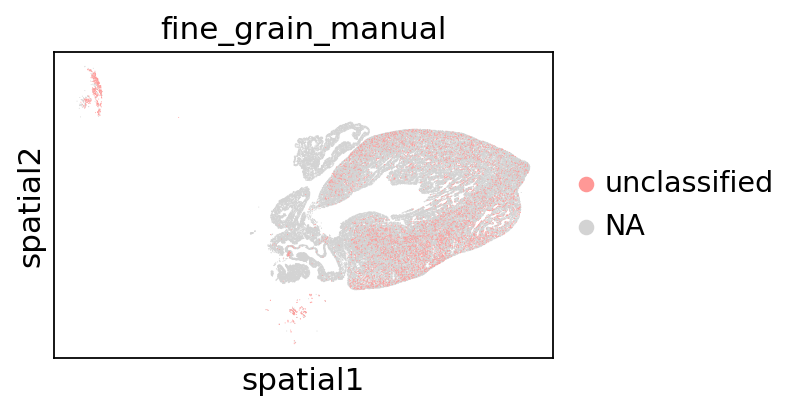

/tmp/ipykernel_702513/3616948915.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


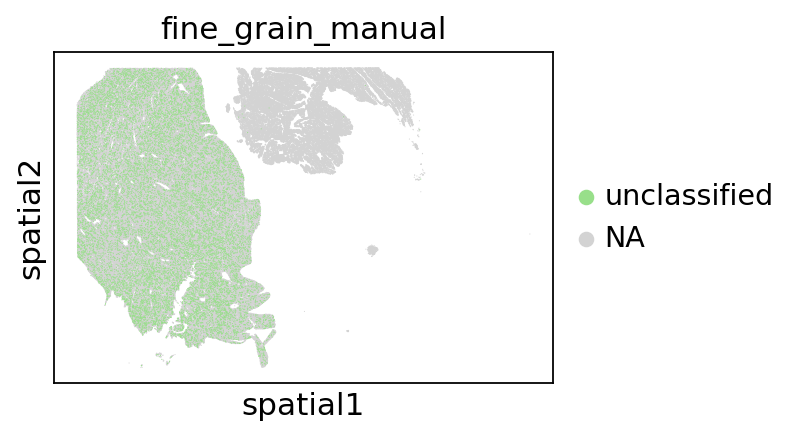

In [16]:
for celltype in set(adata.obs['fine_grain_manual']):
    for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
        slide = adata[adata.obs['tissue_block_id']==tissue_id]
        sc.pl.spatial(slide,color=['fine_grain_manual'],groups=[celltype],
                      spot_size=20,vmax='p100')